# Exercise 3: Segmentation in PyTorch

Welcome to the third exercise of **Generative AI** from the research group **Visual Computing and Artificial Intelligence (VCAI)**!

This notebook deals with the implementation of a U-Net for semantic segmentation. You will load image data, preprocess it appropriately and create datasets. Then you will create and train a basic U-Net model with and without augmented data. In the end you will also expand the model with additional layers and compare the performance.

**You will learn:**
- Input Pipeline:
    - Load image data
    - Augmentation
- U-Net:
    - Create a U-Net with custom layers
- Training:
    - Train the model with custom loss function
    - Comparison of original dataset and augmented dataset as well as comparision between different model depths
    - Visualization

**Note:**  
Please only insert your code in the spaces provided. Any additional cells you have added for testing purposes must be removed before submission.

## Exercise Group Information
- Group Number: FILL IN YOUR GROUP NUMBER
- Group Members: FILL IN THE NAMES OF ALL GROUP MEMBERS

## Table of Contents

- [1. Packages](#1)
    - [1.1 Package Description](#1-1)
    - [1.2 Import Packages](#1-2)
    - [1.3 GPU Usage](#1-3)
- [2. Data](#2)
    - [2.1 Download and Unzip Cityscapes Dataset](#2-1)
    - [2.2 Define Paths](#2-2)
    - [2.3 Augmentation](#2-3)
        - [Exercise 1 - Implement v2.Compose](#ex-1)   
    - [2.4 Training and Validation Dataset](#2-4)  
        - [Exercise 2 - Apply the transformation](#ex-2)
    - [2.5 Analyze the Dataset](#2-5)
- [3. U-Net](#3)
    - [Exercise 3 - Implement a U-Net](#ex-3)
- [4. Training](#4)
    - [4.1 Dice and IoU](#4-1)
        - [Exercise 4 - Dice and IoU coefficients](#ex-4)
    - [4.2 DiceLoss and DiceBCELoss](#4-2)
    - [4.3 Training Loop](#4-3)
    - [4.4 Visualization of the Training](#4-4)
    - [4.5 Training with Augmentation](#4-5)
        - [Exercise 5 - Train the model with the augmented data](#ex-5)
- [5. Expand U-Net](#5)
    - [5.1 Expand U-Net Architecture](#5-1)
        - [Exercise 6 - Expand the U-Net](#ex-6)
    - [5.2 Train expanded U-Net with Augmentation](#5-2)
        - [Exercise 7 - Training of expanded U-Net](#ex-7)
- [6. Comparison and Discussion](#6)
    - [Exercise 8 - Discussion of the results](#ex-3)

<a name="1"></a>
## 1. Packages
<a name="1-1"></a>
### 1.1 Package Description
The following packages are required for this notebook:
- `torch` is a versatile library for machine learning ([Link](https://pytorch.org/)).
- `numpy`  is a library that enables numerical calculations and efficient handling of arrays and matrices ([Link](https://numpy.org/)).
- `matplotlib` is a library for plotting and visualizations ([Link](https://matplotlib.org/)).
- `os` is a module providing operating system dependent functionality ([Link](https://docs.python.org/3/library/os.html)).
- `cv2` is a library for computer vision and machine learning ([Link](https://opencv.org/)).
- `PIL` is a imaging library  ([Link](https://pillow.readthedocs.io/en/stable/)).
- `tqdm` can be used to visualize the training process  ([Link](https://pillow.readthedocs.io/en/stable/)).


<a name="1-2"></a>
### 1.2 Import Packages
Please execute the following cell to import all required packages, dependencies, and custom utility functions.

In [1]:
! pip install torchinfo
import torch
# added subset here
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn as nn
import torch.nn.functional as functional
from torchvision.transforms import v2
import torchinfo
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from PIL import Image
from tqdm import tqdm
from tqdm.notebook import tqdm_notebook
import sys
import numpy as np

Defaulting to user installation because normal site-packages is not writeable


<a name="1-3"></a>
### 1.3 GPU Usage
In order to speed up the training process, it is recommended to use the GPU (see Exercise Information Sheet in OpenOlat).

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


<a name="2"></a>
## 2. Data
<a name="2-1"></a>
### 2.1 Download and Unzip Cityscapes Dataset
The following cell downloads the data set and unzips the file. The folder structure can already be viewed after this step.

In [3]:
! curl -LOC - https://cloud.rz.uni-kiel.de/index.php/s/fDZGqb4tHA36GMc/download/cityscapes_data.zip
! unzip -n cityscapes_data.zip

** Resuming transfer from byte position 105557463
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100   284    0   284    0     0    638      0 --:--:-- --:--:-- --:--:--   638
Archive:  cityscapes_data.zip


<a name="2-2"></a>
### 2.2 Define Paths
In this code section we specify the root path and the paths to the training and the validation data. Furthermore we create a folder to store our trained models.

In [4]:
root_path = './content/'
path_training = root_path + 'cityscapes_data/train'
path_testing =  root_path + 'cityscapes_data/val'
os.makedirs('Unet',exist_ok=True)
path_save = root_path + 'Unet/'

<a name="2-3"></a>
### 2.3 Augmentation
<a name='ex-1'></a>
### Exercise 1 - Implement v2.Compose
In this task you should implement v2 Compose. It should be randomly applied with a probability of 0.5. If it is applied, there should be the random choice between   
- random rotation by 25°,
- random crop with the size of 128 x 128,
- apply a lambda function to adjust the gamma to 2.0,
- random horizontal flip with a probability of 0.5 and
- color jitter with brightness, contrast and saturation =0.5 and hue=0.2.

In [5]:
### START YOUR CODE HERE (REPLACE 'None' with your code) ###

# The whole augmentation pipeline is applied with probability 0.5.
# If applied, exactly one transform is chosen randomly.
custom_transforms = v2.Compose([
    v2.RandomApply([
        v2.RandomChoice([
            v2.RandomRotation(degrees=25),
            v2.RandomCrop(size=(128, 128)),
            v2.Lambda(lambda x: v2.functional.adjust_gamma(x, gamma=2.0)),
            v2.RandomHorizontalFlip(p=0.5),
            v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.2),
        ])
    ], p=0.5)
])

### END OF YOUR CODE ###


<a name="2-4"></a>
### 2.4 Training and Validation Dataset
In this code section the datasets for training and validation are created.  

  
<a name='ex-2'></a>
### Exercise 2 - Apply the transformation
Apply the previously implemented custom transform function within the CustomDataset class.

In [6]:
########

#NOTE: set limit to false to test with full data

#########
enable_limit = True
limit_train=500
limit_val=100

class CustomDataset(Dataset):
    def __init__(self, images_dir, is_augmentation=True, rescale=1.00, target_size=(128, 128), transform=None):
        self.images_dir = images_dir
        self.rescale = rescale
        self.is_augmentation = is_augmentation
        self.target_size = target_size
        self.transform = transform
        self.filenames = [os.path.join(self.images_dir, filename) for filename in os.listdir(self.images_dir)]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        filename = self.filenames[idx]
        img = cv2.imread(filename)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        image = img[:, :256,]
        mask = img[:, 256:]
        image = cv2.resize(image, self.target_size)
        mask = cv2.resize(mask, self.target_size)

        ### START YOUR CODE HERE (REPLACE 'None' with your code) ###

        # Convert numpy arrays to PIL images because torchvision transforms work well with PIL.
        image = Image.fromarray(image)
        mask = Image.fromarray(mask)

        # Apply the same random transform to image and mask.
        # Important: this keeps image-mask alignment after rotation/crop/flip.
        if self.is_augmentation and self.transform is not None:
            image, mask = self.transform(image, mask)

        ### END OF YOUR CODE ###

        image = np.moveaxis(np.array(image), -1, 0).astype(np.float32)
        mask = np.moveaxis(np.array(mask), -1, 0).astype(np.float32)

        image = image / self.rescale
        mask = mask / self.rescale

        return torch.Tensor(image), torch.Tensor(mask)

#Create the Custom Datasets
dataset_train = CustomDataset(images_dir = path_training, is_augmentation=False, transform=custom_transforms,rescale=255.0)
dataset_train_aug= CustomDataset(images_dir = path_training, is_augmentation=True, transform=custom_transforms,rescale=255.0)

dataset_val = CustomDataset(images_dir = path_testing, is_augmentation=False, transform=custom_transforms,rescale=255.0)
dataset_val_aug= CustomDataset(images_dir = path_testing, is_augmentation=True, transform=custom_transforms,rescale=255.0)


# --- Custom enable limit feature


if enable_limit:
    dataset_train = Subset(dataset_train, range(limit_train))
    dataset_val = Subset(dataset_val, range(limit_val))
    
    dataset_train_aug = Subset(dataset_train_aug, range(limit_train))
    dataset_val_aug = Subset(dataset_val_aug, range(limit_val))


<a name="2-5"></a>
### 2.5 Analyze the Dataset
Some example images and the number of samples in the original dataset are plotted/printed and can be analyzed.

torch.Size([1, 3, 128, 128]) torch.Size([1, 3, 128, 128])
torch.Size([1, 3, 128, 128]) torch.Size([1, 3, 128, 128])
Number of samples in training dataset: 500
Number of samples in validation dataset: 100


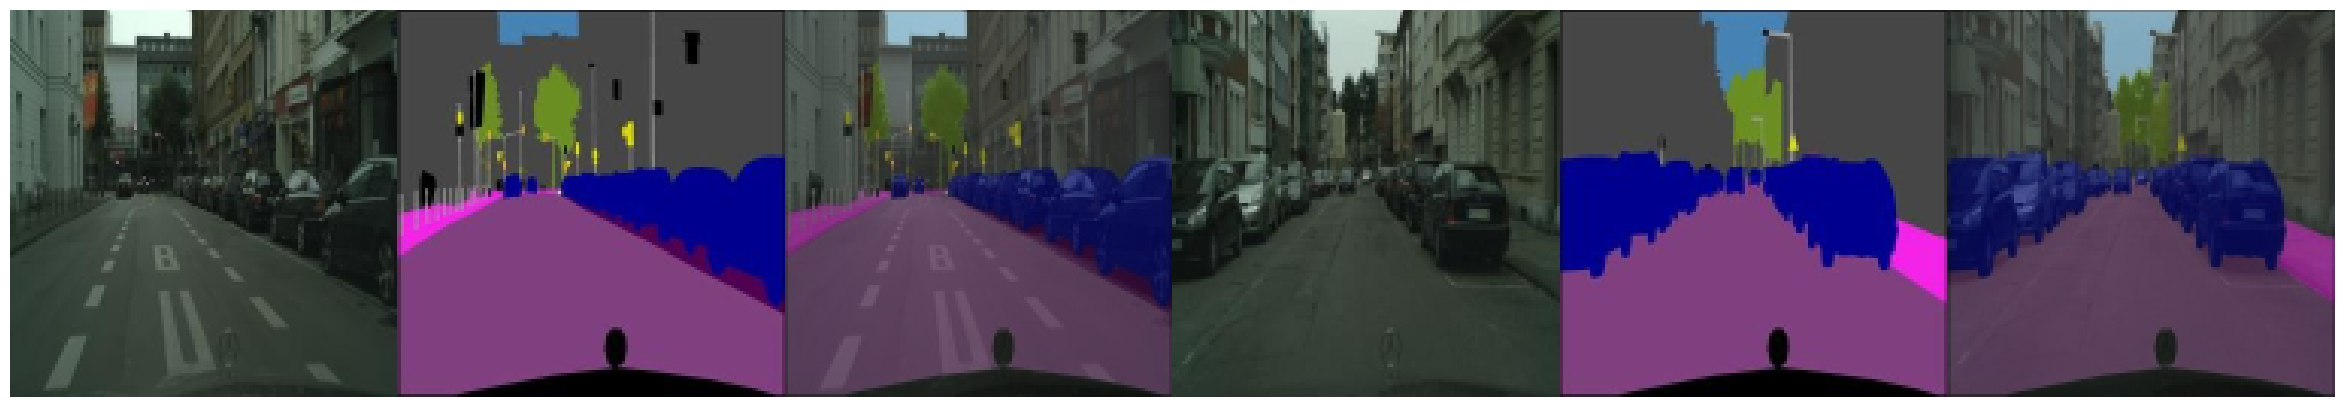

In [7]:
def show_examples(num_cols,dataset,batch_size):
    stacks = []
    # dataloader = dataloader
    dataloader = iter(DataLoader(dataset, batch_size=batch_size, shuffle=True,pin_memory=True))
    for iteration in range(num_cols):
        images, masks = next(dataloader)

        print(images.shape,masks.shape)
        images, masks = images.numpy(), masks.numpy()
        images, masks = np.concatenate(np.moveaxis(images, 1, -1)), np.concatenate(np.moveaxis(masks, 1, -1))
        embedded = (images + masks) / 2
        stack = np.hstack([images, masks, embedded])
        stacks.append(stack)
    result = np.hstack(stacks)
    plt.figure(figsize = (30, 30))
    plt.axis('off')
    plt.imshow(result)

show_examples(2,dataset_train,batch_size=1)

print(f'Number of samples in training dataset: {len(dataset_train)}')
print(f'Number of samples in validation dataset: {len(dataset_val)}')

<a name="3"></a>
## 3. U-Net
<a name='ex-3'></a>
### Exercise 3 - Implement a U-Net
Implement a U-Net according to the given architecture (see image below).

![image.png](https://wetalk.informatik.uni-kiel.de/files/oo65gu9g1ibqfx4bxagw9fxy7c/public?h=Smm-RPmiii3hEen8aJAfNiKrTTxeFH9CrAlHmuAAm2g)

In [8]:
### START YOUR CODE HERE (REPLACE 'None' with your code) ###
class DoubleConv2d(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if mid_channels is None:
            mid_channels = out_channels

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            DoubleConv2d(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels):
        super().__init__()

        # ConvTranspose2d doubles the spatial size.
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)

        # After concatenation, channels become in_channels again.
        self.conv = DoubleConv2d(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        # Make sizes equal before concatenation, in case there is a small mismatch.
        diff_y = x2.size()[2] - x1.size()[2]
        diff_x = x2.size()[3] - x1.size()[3]
        x1 = functional.pad(x1, [diff_x // 2, diff_x - diff_x // 2,
                                 diff_y // 2, diff_y - diff_y // 2])

        # Concatenate skip connection from encoder with decoder feature map.
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv2d(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv2d, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, n_channels, bilinear=True):
        super(UNet, self).__init__()

        self.n_channels = n_channels

        self.inc = DoubleConv2d(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)

        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)

        # Output has 3 channels because the mask image has RGB channels.
        self.outc = OutConv2d(64, 3)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)
        return logits

model_1 = UNet(n_channels=3).to(device)  # Create model_1
torchinfo.summary(model_1, input_size=(1, 3, 128, 128))  # Print summary using torchinfo

### END OF YOUR CODE ###


Layer (type:depth-idx)                        Output Shape              Param #
UNet                                          [1, 3, 128, 128]          --
├─DoubleConv2d: 1-1                           [1, 64, 128, 128]         --
│    └─Sequential: 2-1                        [1, 64, 128, 128]         --
│    │    └─Conv2d: 3-1                       [1, 64, 128, 128]         1,728
│    │    └─BatchNorm2d: 3-2                  [1, 64, 128, 128]         128
│    │    └─ReLU: 3-3                         [1, 64, 128, 128]         --
│    │    └─Conv2d: 3-4                       [1, 64, 128, 128]         36,864
│    │    └─BatchNorm2d: 3-5                  [1, 64, 128, 128]         128
│    │    └─ReLU: 3-6                         [1, 64, 128, 128]         --
├─Down: 1-2                                   [1, 128, 64, 64]          --
│    └─Sequential: 2-2                        [1, 128, 64, 64]          --
│    │    └─MaxPool2d: 3-7                    [1, 64, 64, 64]           --
│    │    └

<a name="4"></a>
## 4. Training
<a name="4-1"></a>
### 4.1 Dice and IoU
The Dice score and the IoU are important metrics for semantic segmentation. We will use the for evaluation and also partly in the loss function.  
<a name='ex-4'></a>
### Exercise 4 - Dice and IoU coefficients
Implement the two function calculating the dice and the IoU coefficient.

In [9]:
### START YOUR CODE HERE (REPLACE 'None' with your code) ###

# Function to calculate the Dice coefficient
def dice_coeff(pred, target, smooth=1.0):
    # Convert raw logits to probabilities
    pred = torch.sigmoid(pred)

    # Flatten everything except batch dimension
    pred = pred.contiguous().view(pred.shape[0], -1)
    target = target.contiguous().view(target.shape[0], -1)

    intersection = (pred * target).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (pred.sum(dim=1) + target.sum(dim=1) + smooth)

    return dice.mean()

# Function to calculate the IoU coefficient
def iou_coeff(pred, target, smooth=1.0):
    # Convert raw logits to probabilities
    pred = torch.sigmoid(pred)

    # Flatten everything except batch dimension
    pred = pred.contiguous().view(pred.shape[0], -1)
    target = target.contiguous().view(target.shape[0], -1)

    intersection = (pred * target).sum(dim=1)
    union = pred.sum(dim=1) + target.sum(dim=1) - intersection
    iou = (intersection + smooth) / (union + smooth)

    return iou.mean()

### END OF YOUR CODE ###


<a name="4-2"></a>
### 4.2 DiceLoss and DiceBCELoss
Based on the previously implemented functions for the Dice coefficients a custom loss function is created.

In [10]:
# Dice Loss class as defined earlier
class DiceLoss(torch.nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)  # Apply sigmoid to get probabilities
        pred = pred.contiguous()
        target = target.contiguous()

        intersection = (pred * target).sum(dim=2).sum(dim=2)

        dice_loss = 1 - ((2. * intersection + self.smooth) / (pred.sum(dim=2).sum(dim=2) + target.sum(dim=2).sum(dim=2) + self.smooth))

        return dice_loss.mean()

# Combined Dice-BCE Loss class as defined earlier
class DiceBCELoss(torch.nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()
        self.bce_loss = torch.nn.BCEWithLogitsLoss(weight=weight, size_average=size_average)
        self.dice_loss = DiceLoss()

    def forward(self, pred, target):
        bce_loss = self.bce_loss(pred, target)
        dice_loss = self.dice_loss(pred, target)
        return bce_loss + dice_loss

<a name="4-3"></a>
### 4.3 Training Loop
The model will be trained in this code section. Due to the usage tqdm the structure is slighly changed compared to the general PyTorch training loop.

In [11]:
epochs = 30

# Training function

def training(model,dataset_train,dataset_val, batch_size,epochs):
    train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True,pin_memory=True)
    val_loader = DataLoader(dataset_val, batch_size=batch_size, shuffle=False,pin_memory=True)

    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-4, betas=(0.9, 0.999), eps=1e-08, weight_decay=0, amsgrad=False)
    criterion = DiceBCELoss()

    history = {
        'train_loss': [],
        'train_dice_coeff': [],
        'train_iou_coeff': [],
        'test_loss': [],
        'test_dice_coeff': [],
        'test_iou_coeff': []
    }

    main_pbar = tqdm_notebook(range(epochs), desc='common progress') #Overall progress bar

    for epoch in main_pbar:
        running_params = {
            'train_loss': [],
            'train_dice_coeff': [],
            'train_iou_coeff': [],
            'test_loss': [],
            'test_dice_coeff': [],
            'test_iou_coeff': []
        }

        train_pbar = tqdm_notebook(range(len(train_loader)), desc=f'Epoch {epoch + 1}/{epochs}') #Training progress bar
        train_iter = iter(train_loader)
        test_iter = iter(val_loader)

        for step in train_pbar:
            model.train()
            train_images, train_masks = next(train_iter)
            train_images, train_masks = train_images.to(device), train_masks.to(device)

            optimizer.zero_grad()

            train_predictions = model(train_images)
            train_loss = criterion(train_predictions, train_masks)
            train_loss.backward()
            optimizer.step()

            train_dice_coeff = dice_coeff(pred=train_predictions, target=train_masks)
            train_iou_coeff = iou_coeff(pred=train_predictions, target=train_masks)

            model.eval()
            with torch.no_grad():
                try:
                    test_images, test_masks = next(test_iter)
                except StopIteration:
                    test_iter = iter(val_loader)
                    test_images, test_masks = next(test_iter)
                test_images, test_masks = test_images.to(device), test_masks.to(device)
                test_predictions = model(test_images)
                test_loss = criterion(test_predictions, test_masks)
                test_dice_coeff = dice_coeff(pred=test_predictions, target=test_masks)
                test_iou_coeff = iou_coeff(pred=test_predictions, target=test_masks)

            current_metrics = {
                'train_loss': train_loss.item(),
                'train_dice_coeff': train_dice_coeff.item(),
                'train_iou_coeff': train_iou_coeff.item(),
                'test_loss': test_loss.item(),
                'test_dice_coeff': test_dice_coeff.item(),
                'test_iou_coeff': test_iou_coeff.item()
            }

            for key in running_params:
                running_params[key].append(current_metrics[key])

            mean_metrics = {key: sum(running_params[key]) / len(running_params[key]) for key in running_params}
            train_pbar.set_postfix(mean_metrics)
            torch.cuda.empty_cache()

        for key in history:
            history[key].append(mean_metrics[key])

    return history



history_1 = training(model=model_1,dataset_train=dataset_train,dataset_val=dataset_val,batch_size=32,epochs=epochs)

torch.save(model_1.state_dict(), path_save + 'model_1.pth')

/home/kranz/.platformio/penv/lib64/python3.14/site-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='mean' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


common progress:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 2/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 3/30:   0%|          | 0/16 [00:00<?, ?it/s]

...

Epoch 26/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 27/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 28/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 29/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 30/30:   0%|          | 0/16 [00:00<?, ?it/s]

<a name="4-4"></a>
### 4.4 Visualization of the Training
The training will be visualized by plotting the loss, the Dice and IoU coefficients for both training and validation.

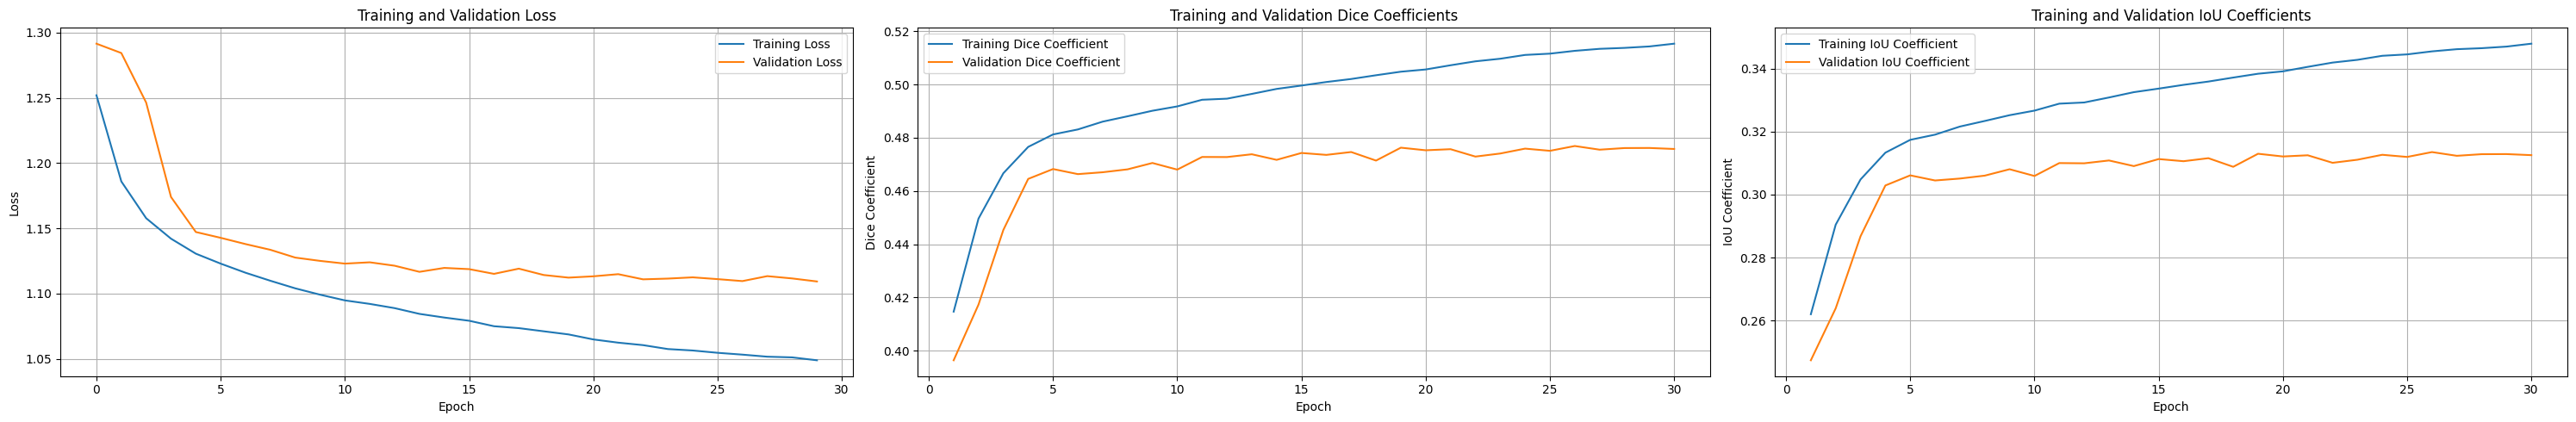

In [12]:
def plot_history(history):

    # Plotting the training and validation loss
    plt.figure(figsize=(30, 5))
    plt.subplot(1,3,1)
    plt.plot(history['train_loss'], label='Training Loss')
    plt.plot(history['test_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid()
    plt.legend()
    plt.title('Training and Validation Loss')

    #  Extracting Dice and IoU coefficients from history
    train_dice_coeff = history['train_dice_coeff']
    test_dice_coeff = history['test_dice_coeff']
    train_iou_coeff = history['train_iou_coeff']
    test_iou_coeff = history['test_iou_coeff']
    epochs = range(1, len(train_dice_coeff) + 1)

    # Plotting Dice coefficient
    plt.subplot(1,3,2)
    plt.plot(epochs, train_dice_coeff, label='Training Dice Coefficient')
    plt.plot(epochs, test_dice_coeff, label='Validation Dice Coefficient')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Coefficient')
    plt.grid()
    plt.legend()
    plt.title('Training and Validation Dice Coefficients')

    # Plotting IoU coefficient
    plt.subplot(1,3,3)
    plt.plot(epochs, train_iou_coeff, label='Training IoU Coefficient')
    plt.plot(epochs, test_iou_coeff, label='Validation IoU Coefficient')
    plt.xlabel('Epoch')
    plt.ylabel('IoU Coefficient')
    plt.grid()
    plt.legend()
    plt.title('Training and Validation IoU Coefficients')

    plt.tight_layout()
    plt.show()


plot_history(history_1)

Furthermore we can plot some example images with their corresponding ground truth mask, predicted mask and overlay of predicted mask and original image.

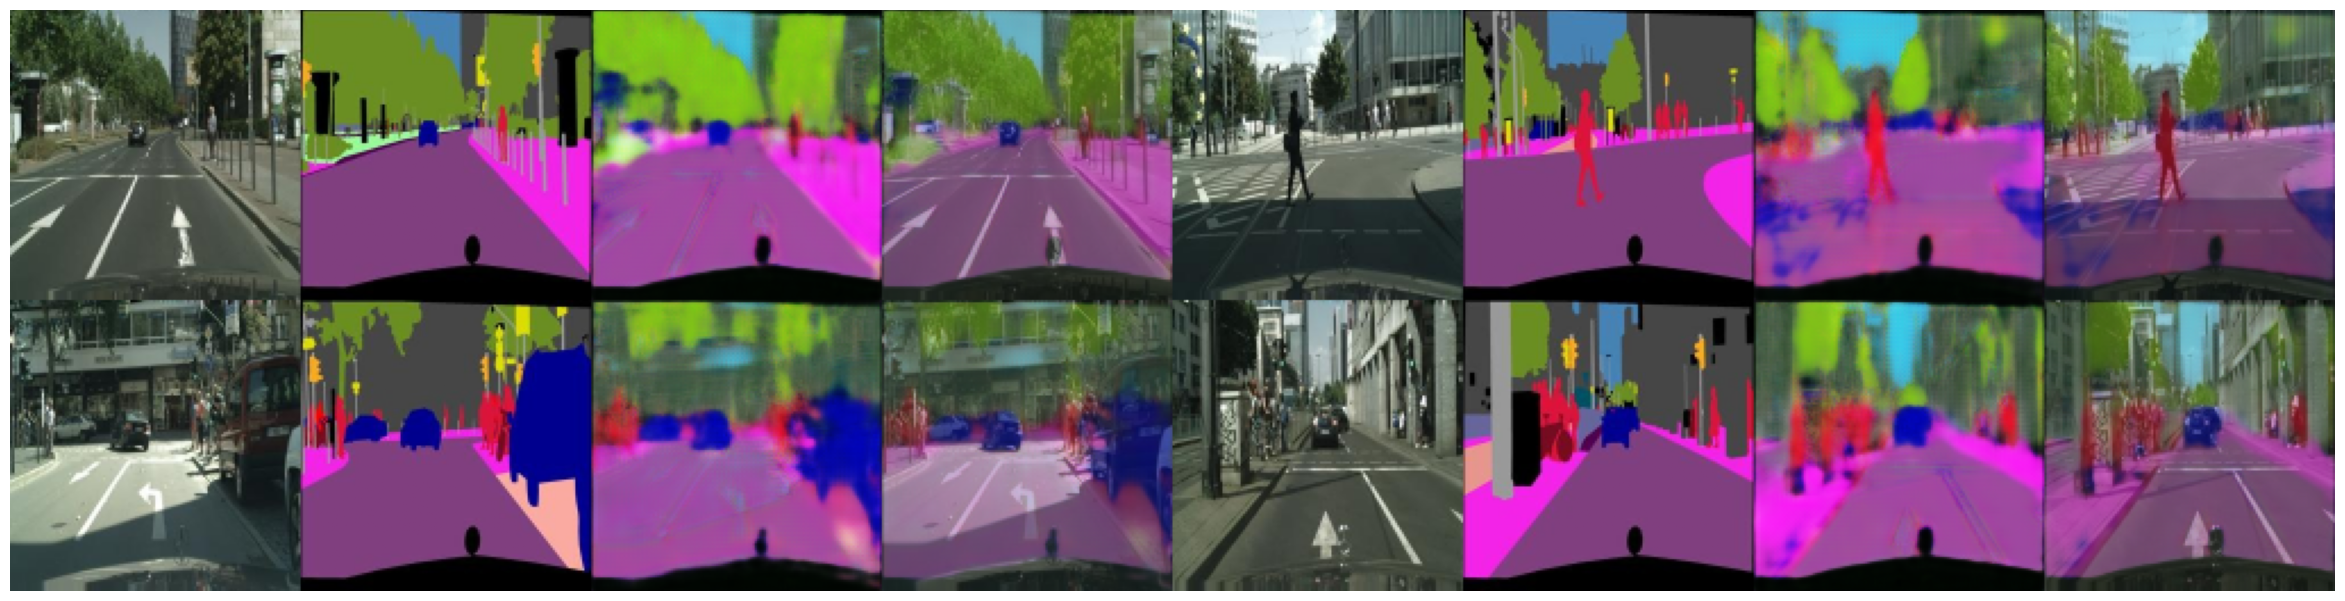

In [13]:
def show_final_result(num_cols,dataset_val,model,batch_size):

    model.to('cpu')
    model.eval()

    test_loader = iter(DataLoader(dataset_val, batch_size=batch_size, shuffle=True,pin_memory=True))

    result = []
    for iteration in range(num_cols):
        images, masks = next(test_loader)

        prediction = torch.sigmoid(model(images))

        prediction = prediction.cpu().detach().numpy()
        prediction = np.moveaxis(prediction, 1, -1)

        masks = np.moveaxis(masks.numpy(), 1, -1)
        images = np.moveaxis(images.numpy(), 1, -1)

        prediction = np.concatenate(prediction)

        images = np.concatenate(images)
        masks = np.concatenate(masks)

        merged = np.add(images, prediction) / 2

        outputs = np.hstack([images, masks, prediction, merged])
        result.append(outputs)

    result = np.hstack(result)
    plt.figure(figsize = (30, 30))
    plt.axis('off')
    plt.imshow(result)

show_final_result(2,dataset_val,model_1,batch_size=2)

<a name="4-5"></a>
### 4.5 Training with Augmentation
<a name='ex-5'></a>
### Exercise 5 - Train the Model with the augmented Data
Create model_2, train it with the augmented dataset (the validation dataset should remain the same). Save the model analog to model_1 and plot the graphs and the example images.

common progress:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 2/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 3/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 4/30:   0%|          | 0/16 [00:00<?, ?it/s]

...

Epoch 26/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 27/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 28/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 29/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 30/30:   0%|          | 0/16 [00:00<?, ?it/s]

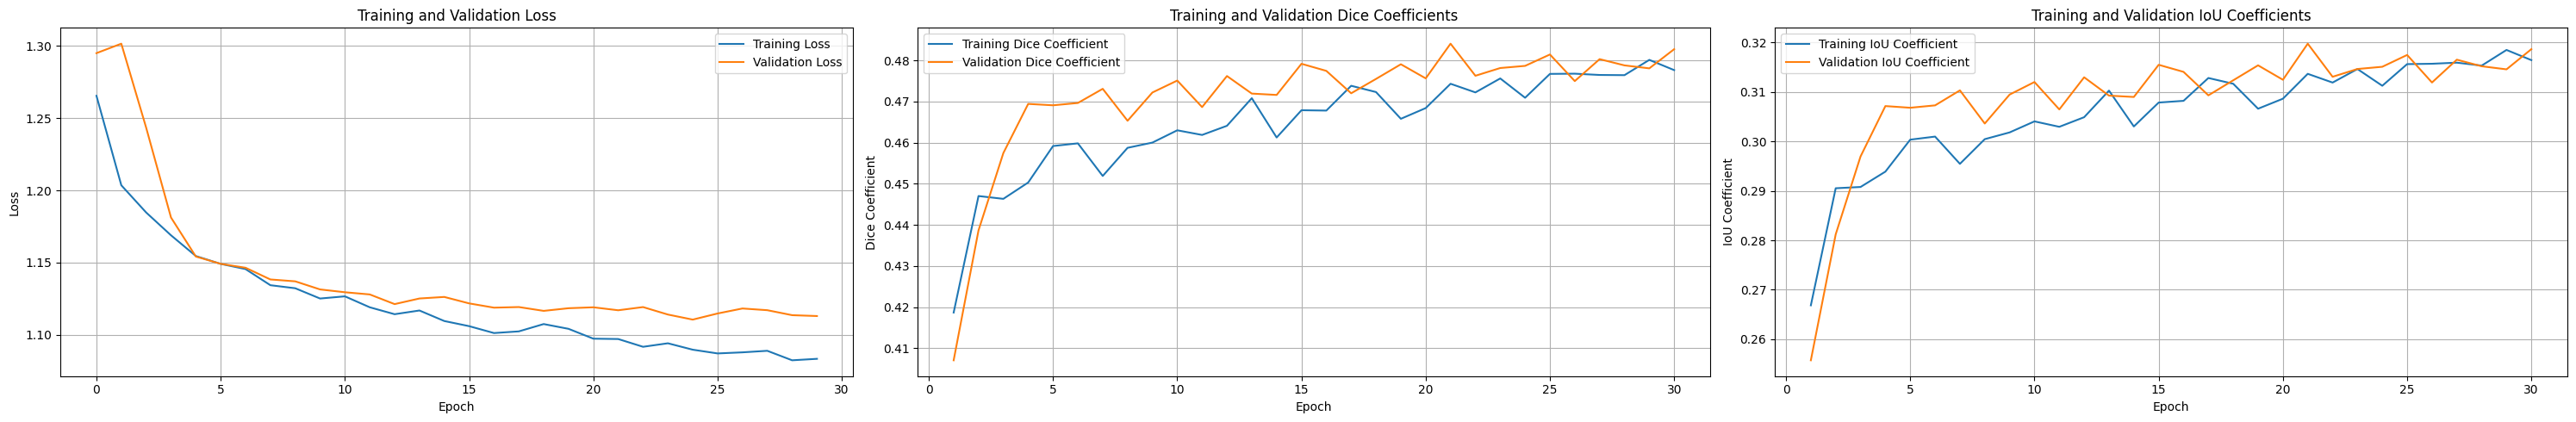

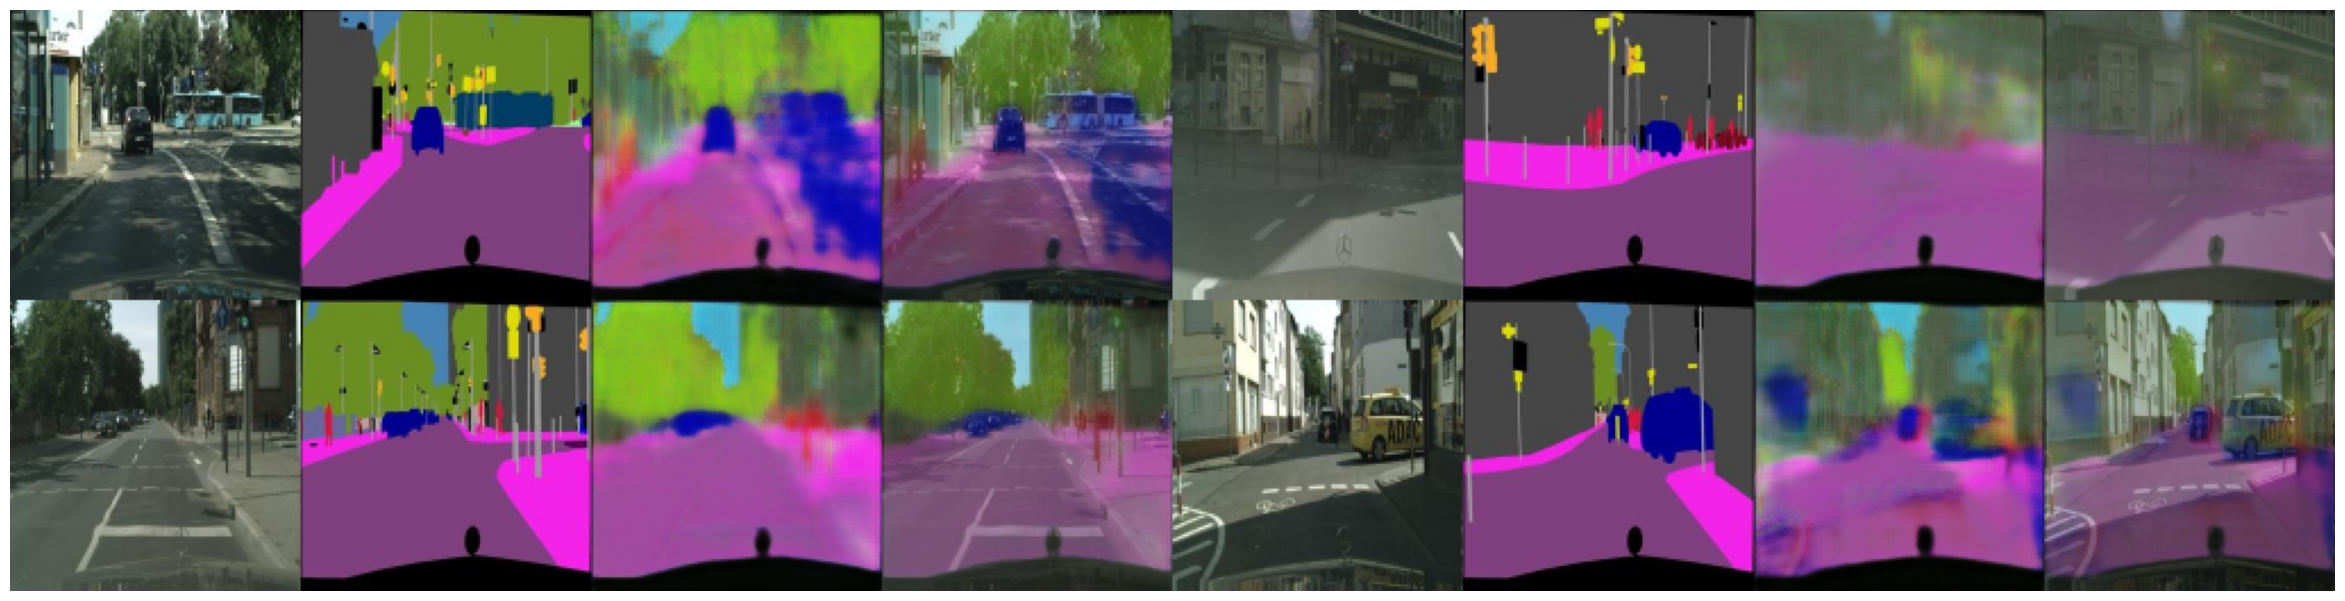

In [14]:
### START YOUR CODE HERE (REPLACE 'None' with your code) ###

model_2 = UNet(n_channels=3).to(device)

history_2 = training(
    model=model_2,
    dataset_train=dataset_train_aug,
    dataset_val=dataset_val,
    batch_size=32,
    epochs=epochs
)

torch.save(model_2.state_dict(), path_save + 'model_2.pth')

plot_history(history_2)
show_final_result(2, dataset_val, model_2, batch_size=2)

### END OF YOUR CODE ###


<a name="5"></a>
## 5. Expand U-Net

<a name="5-1"></a>
### 5.1 Expand U-Net Architecture
For comparison purposes, we want to adapt the architecture of model_1 by expanding it.

<a name='ex-6'></a>
### Exercise 6 - Expand the U-Net
Copy the model implementation of model_1. Rename the classes (eg. by adding _1)In the Up class you should use nn.Upsample instead of nn.ConvTranspose2d. Adjust the architecture and comment every change. The changes should make sense and you should only expand the model (don't delete layers, just add more).

In [15]:
### START YOUR CODE HERE (REPLACE 'None' with your code) ###

class DoubleConv2d_1(nn.Module):
    """Expanded double convolution block."""

    def __init__(self, in_channels, out_channels, mid_channels=None, dropout=0.1):
        super().__init__()
        if mid_channels is None:
            mid_channels = out_channels

        # Change 1: added Dropout2d to reduce overfitting.
        # This expands the block without removing existing conv/bn/relu layers.
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down_1(nn.Module):
    """Downscaling with maxpool then expanded double conv."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            DoubleConv2d_1(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up_1(nn.Module):
    """Upscaling using nn.Upsample then expanded double conv."""

    def __init__(self, in_channels, out_channels):
        super().__init__()

        # Change 2: use nn.Upsample instead of ConvTranspose2d as required.
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # After upsampling, x1 still has in_channels channels.
        # After concatenation with skip connection, we use DoubleConv2d_1.
        self.conv = DoubleConv2d_1(in_channels, out_channels, mid_channels=in_channels // 2)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diff_y = x2.size()[2] - x1.size()[2]
        diff_x = x2.size()[3] - x1.size()[3]
        x1 = functional.pad(x1, [diff_x // 2, diff_x - diff_x // 2,
                                 diff_y // 2, diff_y - diff_y // 2])

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv2d_1(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv2d_1, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet_1(nn.Module):
    def __init__(self, n_channels):
        super(UNet_1, self).__init__()

        self.n_channels = n_channels

        self.inc = DoubleConv2d_1(n_channels, 64)
        self.down1 = Down_1(64, 128)
        self.down2 = Down_1(128, 256)
        self.down3 = Down_1(256, 512)
        self.down4 = Down_1(512, 1024)

        # Change 3: added one extra encoder level.
        # This increases depth and allows the network to learn more global context.
        self.down5 = Down_1(1024, 2048)

        # Change 4: added one matching decoder level.
        # This keeps the U-Net symmetric after adding down5.
        self.up0 = Up_1(2048 + 1024, 1024)
        self.up1 = Up_1(1024 + 512, 512)
        self.up2 = Up_1(512 + 256, 256)
        self.up3 = Up_1(256 + 128, 128)
        self.up4 = Up_1(128 + 64, 64)

        self.outc = OutConv2d_1(64, 3)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # Extra deeper feature map
        x6 = self.down5(x5)

        x = self.up0(x6, x5)
        x = self.up1(x, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)
        return logits


model_3 = UNet_1(n_channels=3).to(device)
torchinfo.summary(model_3, input_size=(1, 3, 128, 128))

### END OF YOUR CODE ###


Layer (type:depth-idx)                        Output Shape              Param #
UNet_1                                        [1, 3, 128, 128]          --
├─DoubleConv2d_1: 1-1                         [1, 64, 128, 128]         --
│    └─Sequential: 2-1                        [1, 64, 128, 128]         --
│    │    └─Conv2d: 3-1                       [1, 64, 128, 128]         1,728
│    │    └─BatchNorm2d: 3-2                  [1, 64, 128, 128]         128
│    │    └─ReLU: 3-3                         [1, 64, 128, 128]         --
│    │    └─Dropout2d: 3-4                    [1, 64, 128, 128]         --
│    │    └─Conv2d: 3-5                       [1, 64, 128, 128]         36,864
│    │    └─BatchNorm2d: 3-6                  [1, 64, 128, 128]         128
│    │    └─ReLU: 3-7                         [1, 64, 128, 128]         --
├─Down_1: 1-2                                 [1, 128, 64, 64]          --
│    └─Sequential: 2-2                        [1, 128, 64, 64]          --
│    │    └

<a name="5-2"></a>
### 5.2 Train expanded U-Net with Augmentation
Train the model_3 with the augmented dataset.
<a name='ex-7'></a>
### Exercise 7 - Training of expanded U-Net
Train the model, plot the graphs and the example images and save the model analog to the previous model.

common progress:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 2/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 3/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 4/30:   0%|          | 0/16 [00:00<?, ?it/s]

...

Epoch 26/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 27/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 28/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 29/30:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 30/30:   0%|          | 0/16 [00:00<?, ?it/s]

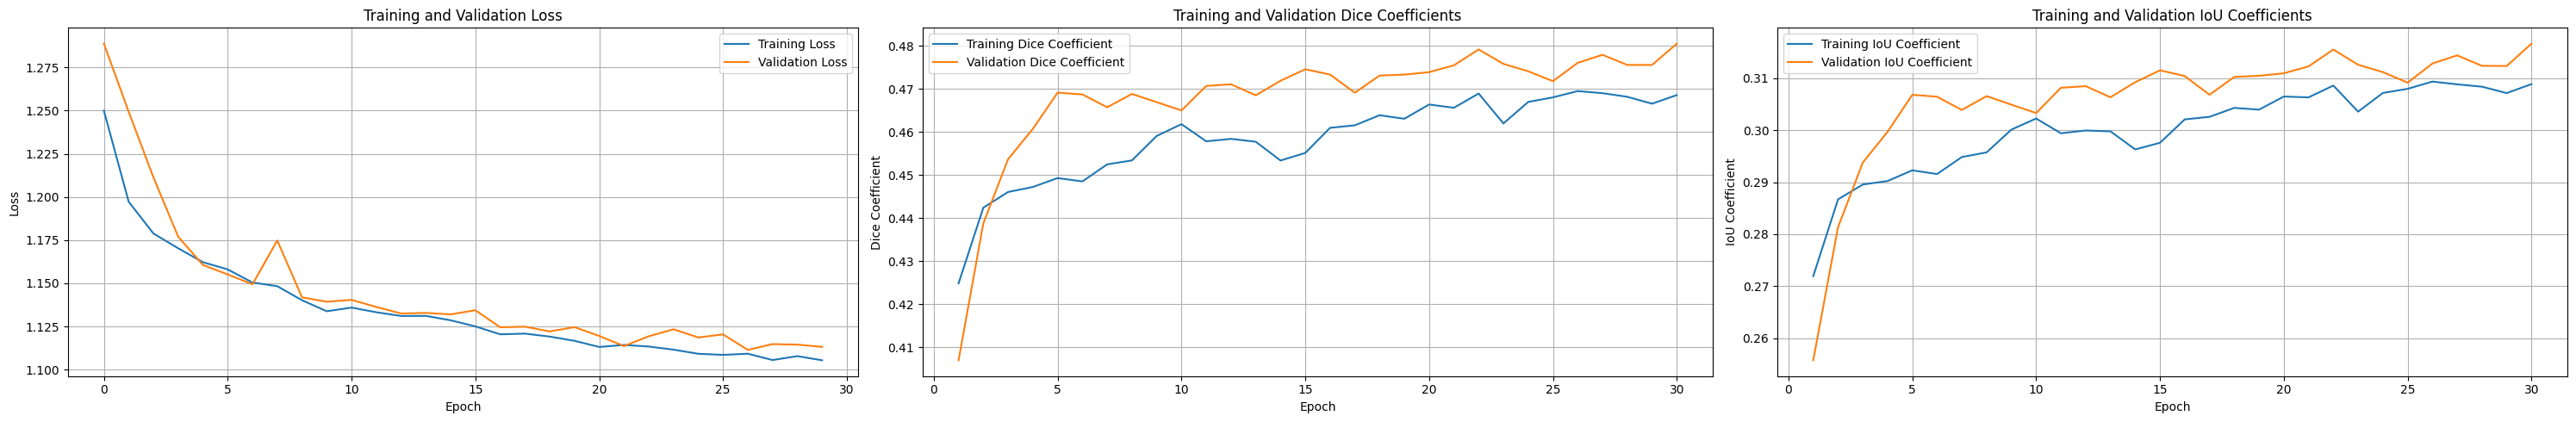

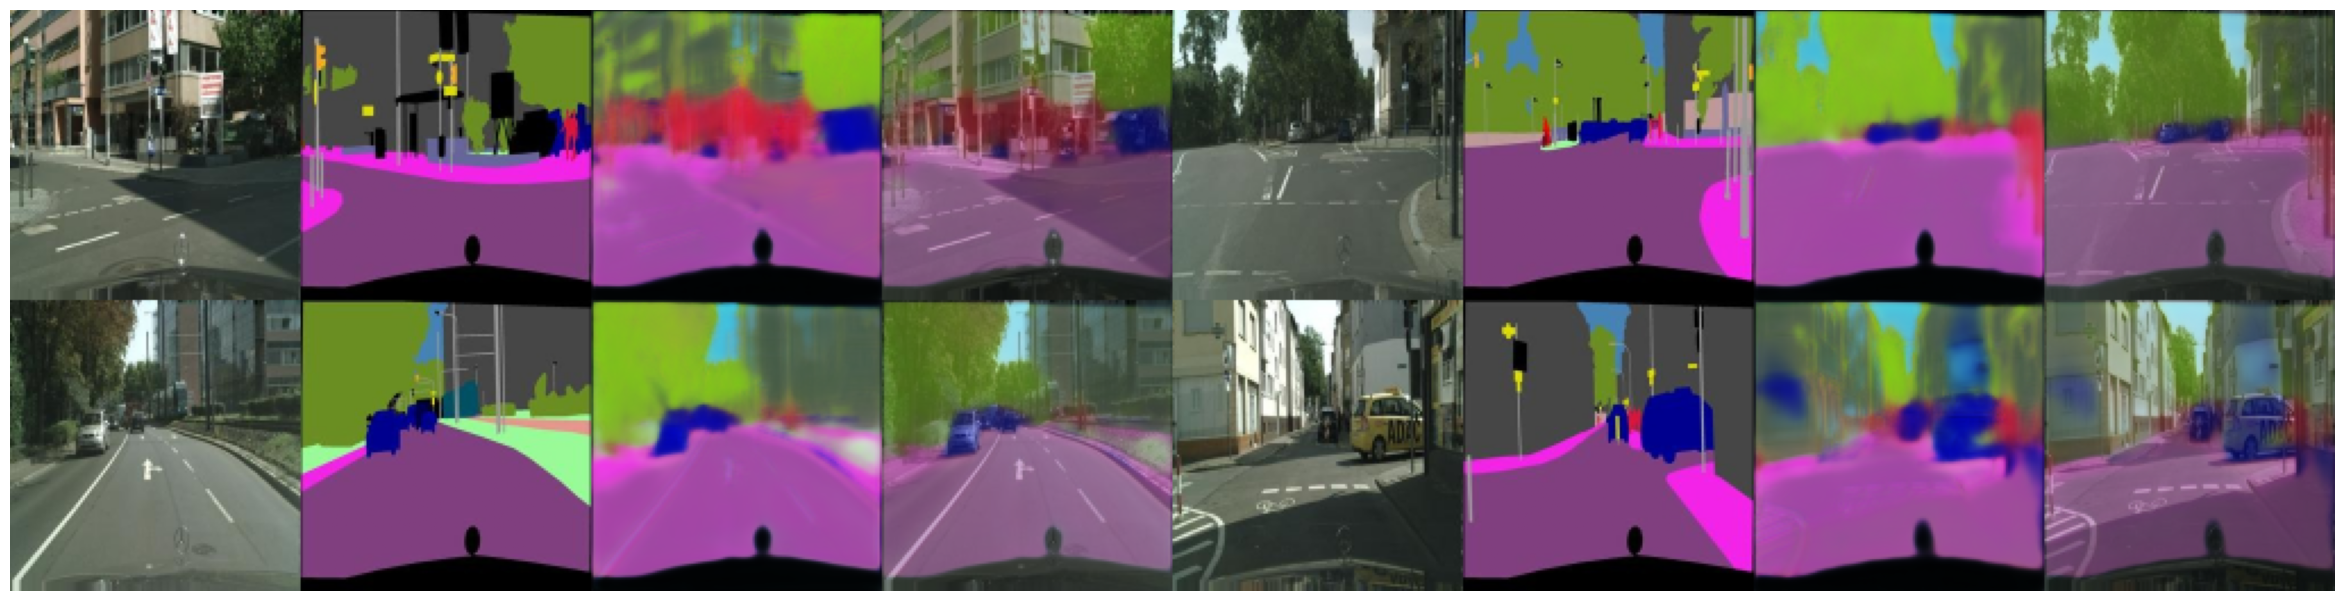

In [16]:
### START YOUR CODE HERE (REPLACE 'None' with your code) ###

history_3 = training(
    model=model_3,
    dataset_train=dataset_train_aug,
    dataset_val=dataset_val,
    batch_size=32,
    epochs=epochs
)

torch.save(model_3.state_dict(), path_save + 'model_3.pth')

plot_history(history_3)
show_final_result(2, dataset_val, model_3, batch_size=2)

### END OF YOUR CODE ###


<a name="6"></a>
## 6. Comparison and Discussion
To compare the three models, we can visualize the results in combined plots.

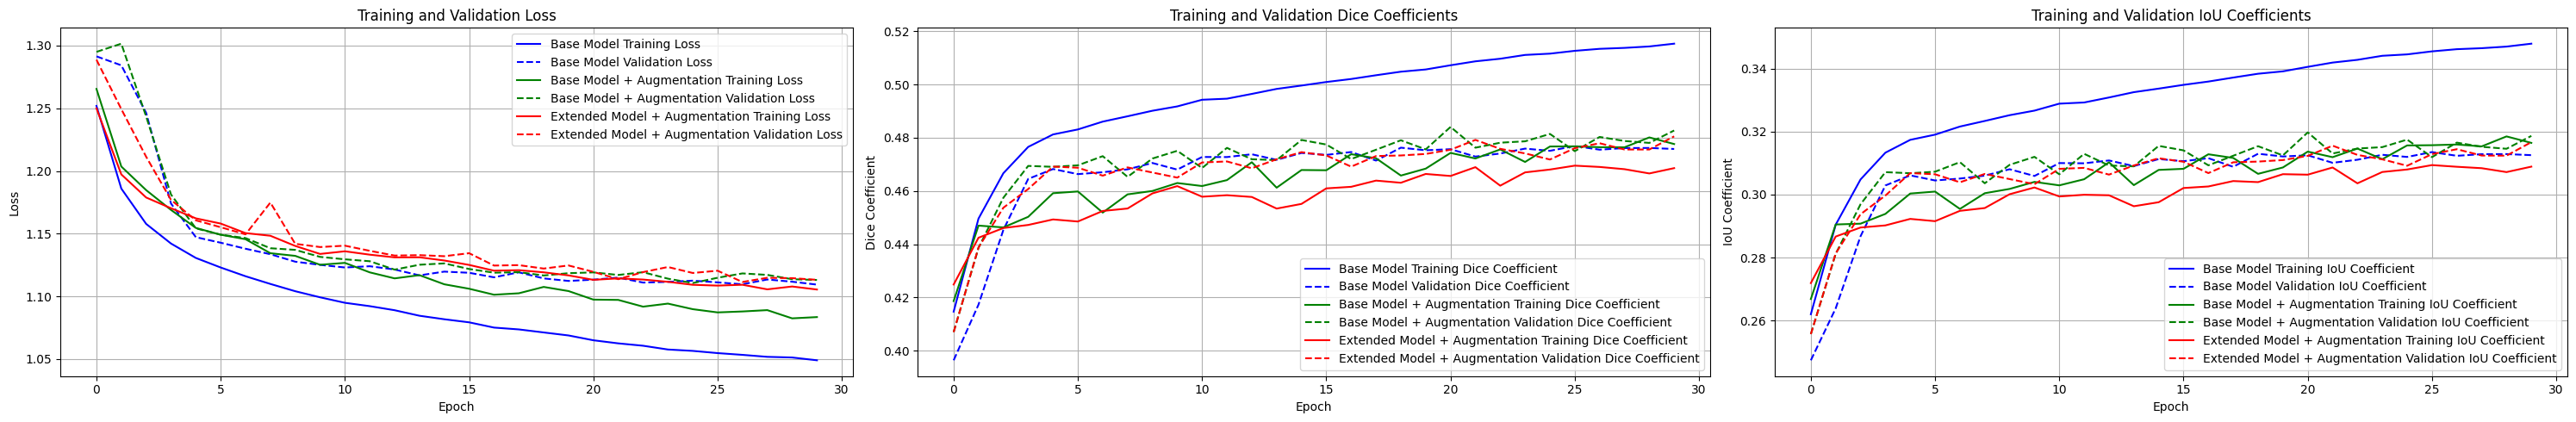

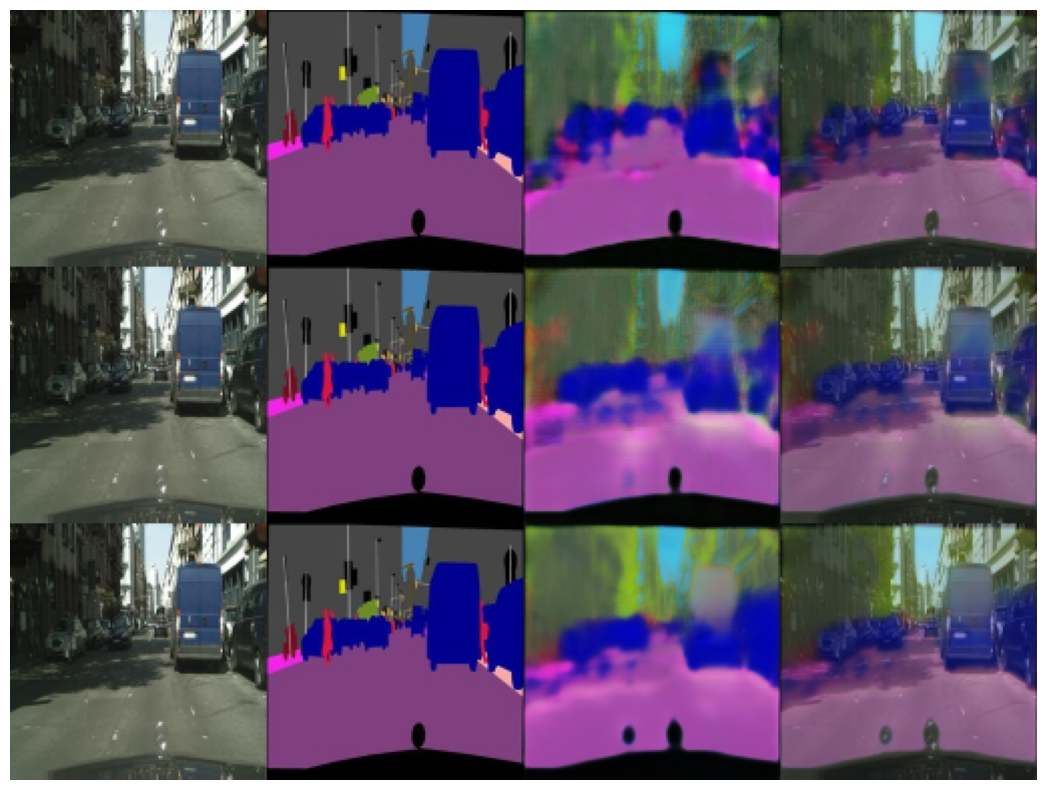

In [17]:
def plot_histories(history1, history2, history3):
    # Create a figure with a specific size
    plt.figure(figsize=(30, 5))

    # List of histories for easier iteration
    histories = [history1, history2, history3]
    labels = ['Base Model', 'Base Model + Augmentation', 'Extended Model + Augmentation']
    colors = ['b', 'g', 'r']

    # Plotting the training and validation loss
    plt.subplot(1, 3, 1)
    for i, history in enumerate(histories):
        plt.plot(history['train_loss'], label=f'{labels[i]} Training Loss', color=colors[i])
        plt.plot(history['test_loss'], label=f'{labels[i]} Validation Loss', linestyle='--', color=colors[i])
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid()
    plt.legend()
    plt.title('Training and Validation Loss')

    # Plotting Dice coefficient
    plt.subplot(1, 3, 2)
    for i, history in enumerate(histories):
        plt.plot(history['train_dice_coeff'], label=f'{labels[i]} Training Dice Coefficient', color=colors[i])
        plt.plot(history['test_dice_coeff'], label=f'{labels[i]} Validation Dice Coefficient', linestyle='--', color=colors[i])
    plt.xlabel('Epoch')
    plt.ylabel('Dice Coefficient')
    plt.grid()
    plt.legend()
    plt.title('Training and Validation Dice Coefficients')

    # Plotting IoU coefficient
    plt.subplot(1, 3, 3)
    for i, history in enumerate(histories):
        plt.plot(history['train_iou_coeff'], label=f'{labels[i]} Training IoU Coefficient', color=colors[i])
        plt.plot(history['test_iou_coeff'], label=f'{labels[i]} Validation IoU Coefficient', linestyle='--', color=colors[i])
    plt.xlabel('Epoch')
    plt.ylabel('IoU Coefficient')
    plt.grid()
    plt.legend()
    plt.title('Training and Validation IoU Coefficients')

    plt.tight_layout()
    plt.show()

# Example usage
plot_histories(history_1, history_2, history_3)


def show_final_results(dataset_val, model1, model2, model3):
    models = [model1, model2, model3]
    for model in models:
        model.to('cpu')
        model.eval()

    test_loader = iter(DataLoader(dataset_val, batch_size=1, shuffle=True,pin_memory=True))

    result = []

    images, masks = next(test_loader)

    # Moveaxis and concatenate images and masks for display
    images_np = np.moveaxis(images.numpy(), 1, -1)
    masks_np = np.moveaxis(masks.numpy(), 1, -1)

    for model in models:
        # Predict and process the output
        prediction = torch.sigmoid(model(images)).cpu().detach().numpy()
        prediction = np.moveaxis(prediction, 1, -1)

        # Combine images, masks, predictions, and merged results for each model
        combined_images = []
        for img, mask, pred in zip(images_np, masks_np, prediction):
            merged = (img + pred) / 2
            combined_images.extend([img, mask, pred, merged])
        combined_images = np.hstack(combined_images)
        result.append(combined_images)

    # Stack all results for all iterations vertically
    final_result = np.vstack(result)
    plt.figure(figsize=(30, 10))
    plt.axis('off')
    plt.imshow(final_result)
    plt.show()

# Example usage
show_final_results(dataset_val, model_1, model_2, model_3)



### Exercise 8 - Discussion of the results
Discuss the results from the three models quantitatively and qualitatively. Use the graphs and the images, explain differences in detail and also possible reasons for the different behaviors/performances of the models.



### Base Model

From the results, we concluded that the Base Model is overfitting. This is evidenced by the wide, diverging gap between the training and validation curves. Additionally, the massive deviation of its training Dice score from the other models suggests a severe lack of generalization. The qualitative results confirm this; the merged segmentation images are highly noisy and erratic. This occurs because the model is essentially memorizing the exact pixel layouts of the small training set rather than learning generalized features.

### Base Model + Augmentation

This configuration is our best-performing model. It demonstrates a steadily decreasing loss while maintaining an incredibly close gap between the training and validation curves. Visually, the merged evaluation images show significantly less noise, sharper boundaries, and vastly superior structural coherence when compared directly to the unaugmented Base Model.

### Extended Model

Our attempt to scale the architecture by adding an extra layer and dropout did not yield the expected performance improvements. In its current state, the model is underfitting, which we suspect is a direct consequence of restricting our dataset to just 500 images. Because an extended model possesses a higher parameter count, it requires a much larger data volume to optimize successfully. Given a significantly larger dataset, this model would likely overcome its current limitations and eventually outperform the simpler Base Model.

## Congratulations

You've finished the third exercise in PyTorch. In this notebook you learnt how to implement and train a U-Net for semantic segmentation.